## EDA - Exploratory Data Analisis

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
import regex as re
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

## Problem statement

>In this notebook, We performed a comprehensive Exploratory Data Analysis (EDA) and data preprocessing to prepare an emotion-based dataset. The goal is to predict emotions from text.

## Data loading

In [62]:
df = pd.read_csv("../data/processed/full_data.csv")
df.head()

,text,emotion
0,@tiffanylue i know i was listenin to bad habi...,sad
1,Layin n bed with a headache ughhhh...waitin o...,sad
2,Funeral ceremony...gloomy friday...,sad
3,wants to hang out with friends SOON!,joy
4,Re-pinging @ghostridah14: why didn't you go to...,fear


## Descriptive analysis

In [63]:
df.shape

(496222, 2)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496222 entries, 0 to 496221
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     496222 non-null  object
 1   emotion  496222 non-null  object
dtypes: object(2)
memory usage: 7.6+ MB


In [65]:
df.describe(include='all')

,text,emotion
count,496222,496222
unique,496222,5
top,@tiffanylue i know i was listenin to bad habi...,joy
freq,1,208380


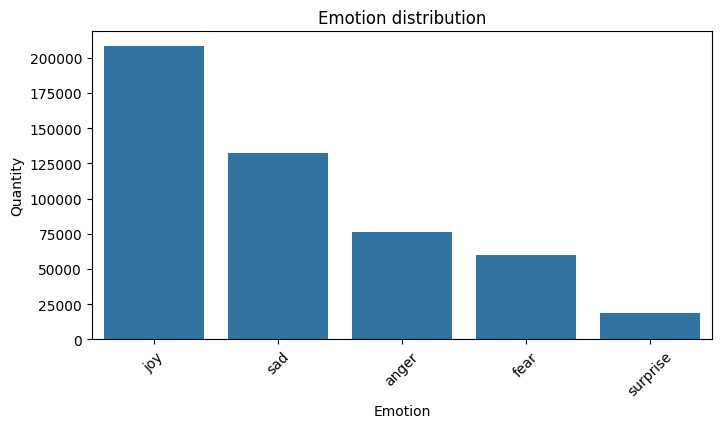

In [66]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)
plt.title('Emotion distribution')
plt.xlabel('Emotion')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.show()

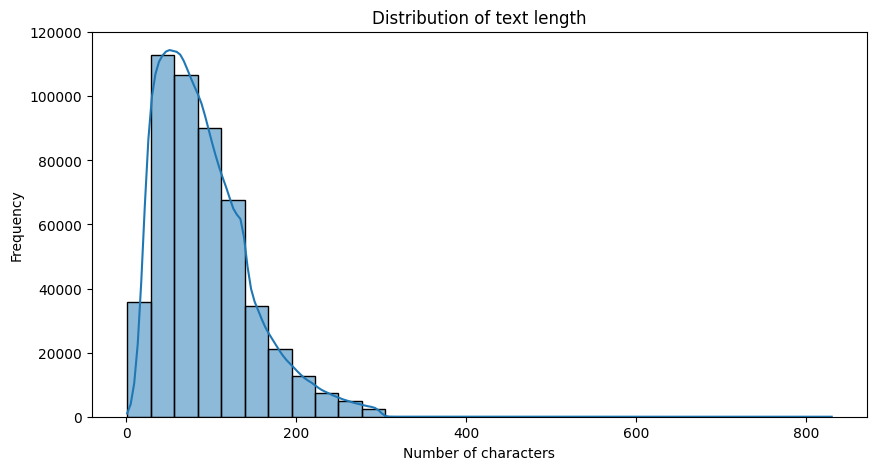

In [67]:
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title('Distribution of text length')
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.show()

In [68]:
df['text_length'].describe()

count    496222.000000
mean         91.911973
std          54.085156
min           1.000000
25%          51.000000
50%          82.000000
75%         122.000000
max         830.000000
Name: text_length, dtype: float64

/tmp/ipykernel_38785/3825464907.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')


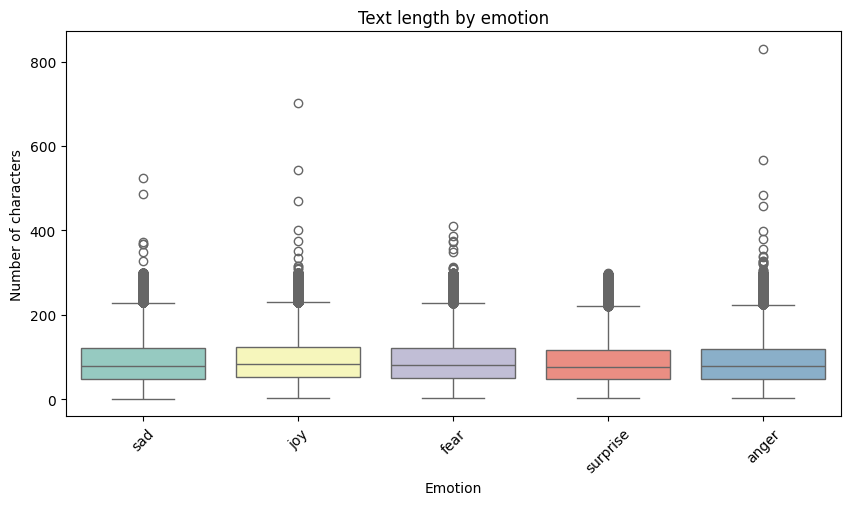

In [69]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')
plt.title('Text length by emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of characters')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_38785/2490167661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')


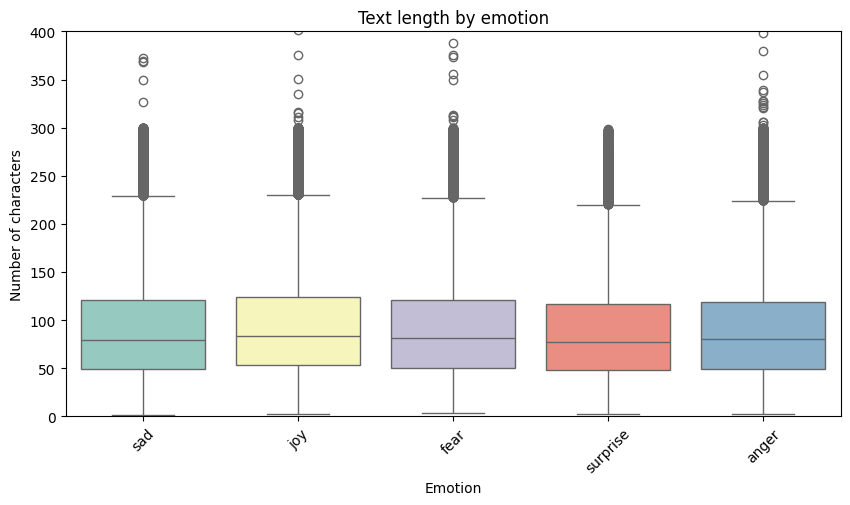

In [70]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')
plt.title('Text length by emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of characters')
plt.ylim(0, 400)
plt.xticks(rotation=45)
plt.show()

>In the second Boxplot we limited the y to 400 to make it more clear

In [71]:
df['emotion'].value_counts()

emotion
joy         208380
sad         132290
anger        76359
fear         60154
surprise     19039
Name: count, dtype: int64

>Here we can see how many values are for each emotion

In [72]:
examples = {}
for emotion in df['emotion'].unique():
    examples[emotion] = df[df['emotion'] == emotion]['text'].head(1)

examples

{'sad': 0    @tiffanylue i know  i was listenin to bad habi...
 Name: text, dtype: object,
 'joy': 3    wants to hang out with friends SOON!
 Name: text, dtype: object,
 'fear': 4    Re-pinging @ghostridah14: why didn't you go to...
 Name: text, dtype: object,
 'surprise': 12    Got the news
 Name: text, dtype: object,
 'anger': 27    It is so annoying when she starts typing on he...
 Name: text, dtype: object}

## Data Cleaning

>Data is already cleaned from the data-treatment-merge.ipynb notebook.

## Variable analysis

>You can see some variable analisis also in the descriptive analisis. Here you can see some statistical analisis of the text length for each emotion.

In [ ]:
df.groupby('emotion')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
emotion,,,,,,,,
anger,76359.0,89.617517,53.657265,2.0,49.0,80.0,119.0,830.0
fear,60154.0,90.864465,52.897146,4.0,50.0,81.0,121.0,411.0
joy,208380.0,94.042878,54.265618,2.0,53.0,84.0,124.0,703.0
sad,132290.0,90.999970,54.628499,1.0,49.0,79.0,121.0,525.0
surprise,19039.0,87.438258,52.799201,3.0,48.0,77.0,117.0,299.0


## Feature engineering

>The only Outliers we have are in text_length and we won'n use that data to train our model so we won't see or treat more their outliers.

>There is no missing data as we treated all the data in other notebooks as data-treatment-merge.ipynb

>There is no new features to make

In [76]:

# Separar variables predictoras (X) y variable objetivo (y)
X = df['text']
y = df['emotion']

# Split 80% train, 20% test, estratificando por emoción
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño de train:", X_train.shape)
print("Tamaño de test:", X_test.shape)
print("Distribución de emociones en train:\n", y_train.value_counts(normalize=True))
print("Distribución de emociones en test:\n", y_test.value_counts(normalize=True))

Tamaño de train: (396977,)
Tamaño de test: (99245,)
Distribución de emociones en train:
 emotion
joy         0.419934
sad         0.266595
anger       0.153880
fear        0.121224
surprise    0.038367
Name: proportion, dtype: float64
Distribución de emociones en test:
 emotion
joy         0.419930
sad         0.266593
anger       0.153882
fear        0.121225
surprise    0.038370
Name: proportion, dtype: float64


## WordCloud

In [78]:
def preprocess_text(text):
    text = text.lower()
    #text = re.sub("https?|www", " ", text)
    text = re.sub(r'[^a-z ]', " ", text)
    text = re.sub(r'\s+', " ", text)
    return text.split()

In [79]:
download("wordnet")
lemmatizer = WordNetLemmatizer()

download("stopwords")
stop_words = stopwords.words("english")

def lemmatize_text(words, lemmatizer=lemmatizer):
    tokens = [lemmatizer.lemmatize(word) for word in words]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 2]
    return tokens

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [80]:
df["text"] = df["text"].apply(preprocess_text)
df["text"] = df["text"].apply(lemmatize_text)
df

,text,emotion,text_length
0,"[tiffanylue, know, listenin, bad, habit, earli...",sad,92
1,"[layin, bed, headache, ughhhh, waitin, call]",sad,60
2,"[funeral, ceremony, gloomy, friday]",sad,35
3,"[want, hang, friend, soon]",joy,36
4,"[pinging, ghostridah, prom, like, friend]",fear,84
...,...,...,...
496217,"[born, without, little, finger, right, hand]",surprise,51
496218,"[license, plate]",surprise,22
496219,"[welded, rose, mum, birthday]",surprise,38
496220,"[two, different, set, shopping, basket, depart...",surprise,130


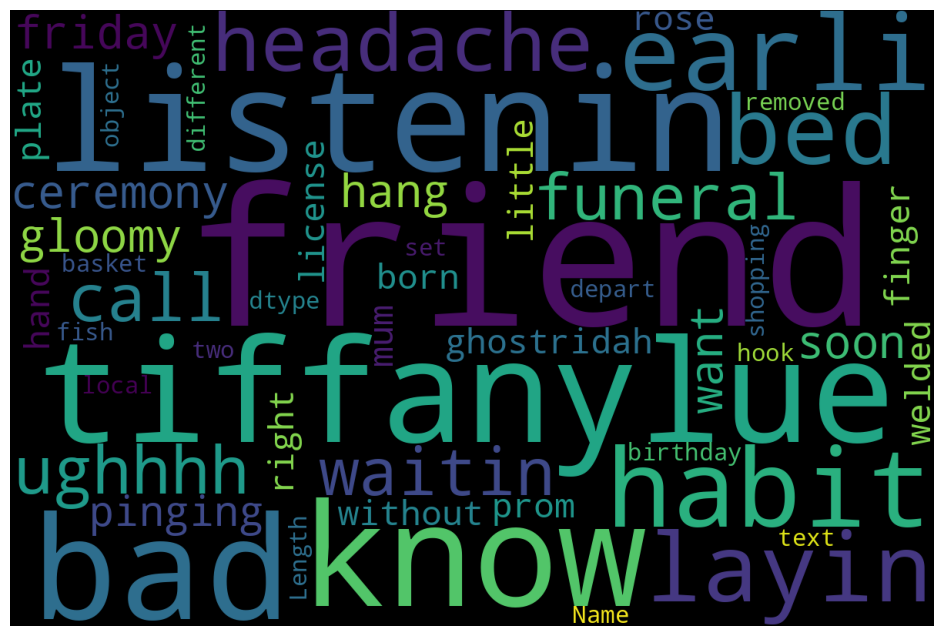

In [81]:
wordcloud = WordCloud(width=1200,
                      height=800,
                      background_color="black",
                      max_words=1000,
                      min_font_size=20,
                      random_state=25).generate(str(df["text"]))

fig = plt.figure(figsize=(12, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()